In [1]:
# poker_stage1_improved.ipynb
# Stage 1: Improved Supervised Learning Poker Bot
# Improvements:
# 1. Class-weighted loss for imbalanced data
# 2. Enhanced features (pot odds, SPR, hand strength, opponent info)
# 3. Hand-based train/test split (no data leakage)
# 4. Stack-relative normalization
# 5. Comprehensive evaluation against multiple bot types
# 6. Self-play fine-tuning stage

import requests
import re
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import copy

# Config
CONFIG = {
    'n_files': None,  # None = use all
    'batch_size': 128,  # larger batch for stability
    'learning_rate': 0.0003,
    'n_epochs': 20,
    'hidden_dims': [512, 512, 256, 128],
    'test_size': 0.2,
    'random_seed': 42,
    'use_local': True,
    'local_root': r'F:\workspace\poker_claudecode\simple_datasets',
    'allowed_variants': ['NT', 'FT'],
    'min_players': 3,
    'local_cache_file': 'local_data_cache.pkl',
    # New configs for improvements
    'use_class_weights': True,
    'use_focal_loss': False,  # alternative to class weights
    'focal_gamma': 2.0,
    # Self-play fine-tuning config
    'selfplay_epochs': 10,
    'selfplay_lr': 0.0001,
    'selfplay_games_per_epoch': 1000,
}

# Set random seeds
np.random.seed(CONFIG['random_seed'])
torch.manual_seed(CONFIG['random_seed'])

# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"Config: {CONFIG}")

Using device: cuda
Config: {'n_files': None, 'batch_size': 128, 'learning_rate': 0.0003, 'n_epochs': 20, 'hidden_dims': [512, 512, 256, 128], 'test_size': 0.2, 'random_seed': 42, 'use_local': True, 'local_root': 'F:\\workspace\\poker_claudecode\\simple_datasets', 'allowed_variants': ['NT', 'FT'], 'min_players': 3, 'local_cache_file': 'local_data_cache.pkl', 'use_class_weights': True, 'use_focal_loss': False, 'focal_gamma': 2.0, 'selfplay_epochs': 10, 'selfplay_lr': 0.0001, 'selfplay_games_per_epoch': 1000}


In [2]:
# Cell 2: Data fetching (same as before, with hand_id tracking)
import pickle
import os
import glob

def parse_phh_hand(phh_text):
    """Parse PHH text into structured data"""
    hand = {}
    
    variant_match = re.search(r"variant = '(\w+)'", phh_text)
    if variant_match:
        hand['variant'] = variant_match.group(1)
    
    antes_match = re.search(r"antes = \[([\d, ]+)\]", phh_text)
    if antes_match:
        hand['antes'] = [int(x.strip()) for x in antes_match.group(1).split(',')]
    
    blinds_match = re.search(r"blinds_or_straddles = \[([\d, ]+)\]", phh_text)
    if blinds_match:
        hand['blinds'] = [int(x.strip()) for x in blinds_match.group(1).split(',')]
    
    stacks_match = re.search(r"starting_stacks = \[([\d, ]+)\]", phh_text)
    if stacks_match:
        hand['starting_stacks'] = [int(x.strip()) for x in stacks_match.group(1).split(',')]
    
    actions_match = re.search(r"actions = \[(.*?)\]", phh_text, re.DOTALL)
    if actions_match:
        actions_str = actions_match.group(1)
        action_list = re.findall(r"'([^']+)'", actions_str)
        hand['actions'] = action_list
    
    players_match = re.search(r"players = \[(.*?)\]", phh_text)
    if players_match:
        players_str = players_match.group(1)
        hand['players'] = [p.strip().strip("'") for p in players_str.split(',')]
    
    return hand

def _should_keep_by_filters(phh_text):
    hand = parse_phh_hand(phh_text)
    variant = hand.get('variant')
    players = hand.get('players', [])
    actions = hand.get('actions', [])

    if "????" in phh_text:
        return False
    if any("????" in a for a in actions):
        return False
    if variant is None or not players:
        return False
    if len(players) < CONFIG.get('min_players', 3):
        return False
    allowed = set(CONFIG.get('allowed_variants', ['NT','FT']))
    return variant in allowed

def _load_local_phh_files(root_dir, n_files=None, use_cache=True):
    cache_path = CONFIG.get('local_cache_file', 'local_data_cache.pkl')
    if use_cache and os.path.exists(cache_path):
        print(f"Loading from local cache: {cache_path}")
        with open(cache_path, 'rb') as f:
            cached = pickle.load(f)
        print(f"Loaded {len(cached)} files from local cache")
        return cached[:n_files] if n_files is not None else cached

    patterns = [os.path.join(root_dir, '**', '*.phh'),
                os.path.join(root_dir, '**', '*.phhs'),
                os.path.join(root_dir, '**', '*.PHH'),
                os.path.join(root_dir, '**', '*.PHHS')]
    candidates = []
    for pat in patterns:
        candidates.extend(glob.glob(pat, recursive=True))

    print(f"Found {len(candidates)} candidate PHH files under {root_dir}")
    phh_texts = []
    kept = 0

    for path in candidates:
        try:
            with open(path, 'r', encoding='utf-8', errors='ignore') as f:
                text = f.read()
        except Exception as e:
            continue

        if _should_keep_by_filters(text):
            phh_texts.append(text)
            kept += 1
            if n_files is not None and kept >= n_files:
                break
            if kept % 5000 == 0:
                print(f'  -> kept so far: {kept}')

    print(f'Kept {kept} PHH files after filters')

    if use_cache:
        with open(cache_path, 'wb') as f:
            pickle.dump(phh_texts, f)
        print(f'Local cache saved -> {cache_path}')

    return phh_texts

def download_pluribus_files(n_files=None, use_cache=True):
    if CONFIG.get('use_local', False):
        root = CONFIG.get('local_root', '.')
        print(f'[Local mode] Reading PHH from: {root}')
        return _load_local_phh_files(root, n_files=n_files, use_cache=use_cache)
    raise RuntimeError("Remote download disabled.")

print("Data loading functions ready")

Data loading functions ready


In [3]:
# Cell 3: Parsing functions
def parse_cards(card_str):
    """Parse card string into list of cards (e.g., 'TcQc' -> ['Tc', 'Qc'])"""
    cards = []
    i = 0
    while i < len(card_str):
        if i + 1 < len(card_str):
            cards.append(card_str[i:i+2])
            i += 2
        else:
            i += 1
    return cards

def card_to_index(card):
    """Convert card to 0-51 index"""
    if len(card) != 2:
        return -1
    
    rank_map = {'2': 0, '3': 1, '4': 2, '5': 3, '6': 4, '7': 5, '8': 6, 
                '9': 7, 'T': 8, 'J': 9, 'Q': 10, 'K': 11, 'A': 12}
    suit_map = {'c': 0, 'd': 1, 'h': 2, 's': 3}
    
    rank = card[0]
    suit = card[1]
    
    if rank in rank_map and suit in suit_map:
        return rank_map[rank] * 4 + suit_map[suit]
    return -1

print("Parsing functions ready")

Parsing functions ready


In [4]:
# Cell 4: Hand Strength Evaluation (NEW)
# Simple hand strength calculator without external dependencies

def get_rank_value(card):
    """Get numeric rank value (2=0, A=12)"""
    rank_map = {'2': 0, '3': 1, '4': 2, '5': 3, '6': 4, '7': 5, '8': 6, 
                '9': 7, 'T': 8, 'J': 9, 'Q': 10, 'K': 11, 'A': 12}
    return rank_map.get(card[0], -1)

def get_suit(card):
    """Get suit character"""
    return card[1] if len(card) == 2 else None

def calculate_preflop_strength(hole_cards):
    """
    Calculate preflop hand strength (0-1 scale)
    Based on Sklansky hand rankings approximation
    """
    if len(hole_cards) != 2:
        return 0.5
    
    r1 = get_rank_value(hole_cards[0])
    r2 = get_rank_value(hole_cards[1])
    s1 = get_suit(hole_cards[0])
    s2 = get_suit(hole_cards[1])
    
    if r1 < 0 or r2 < 0:
        return 0.5
    
    high = max(r1, r2)
    low = min(r1, r2)
    is_pair = (r1 == r2)
    is_suited = (s1 == s2)
    gap = high - low
    
    # Base strength from high card
    strength = (high + low) / 24.0  # normalize to 0-1
    
    # Pair bonus
    if is_pair:
        strength += 0.3 + (high / 12.0) * 0.2  # higher pairs worth more
    
    # Suited bonus
    if is_suited:
        strength += 0.05
    
    # Connector bonus (straight potential)
    if gap == 1:
        strength += 0.03
    elif gap == 2:
        strength += 0.02
    
    # Broadway cards bonus (T+)
    if high >= 8 and low >= 8:
        strength += 0.05
    
    # Premium hands boost
    if is_pair and high >= 10:  # JJ+
        strength += 0.1
    if high == 12 and low >= 10:  # AK, AQ, AJ
        strength += 0.08
    
    return min(1.0, max(0.0, strength))

def calculate_postflop_strength(hole_cards, board_cards):
    """
    Calculate postflop hand strength (simplified)
    Returns value 0-1 based on made hand + draw potential
    """
    if len(hole_cards) != 2 or len(board_cards) < 3:
        return calculate_preflop_strength(hole_cards)
    
    all_cards = hole_cards + board_cards
    ranks = [get_rank_value(c) for c in all_cards if get_rank_value(c) >= 0]
    suits = [get_suit(c) for c in all_cards if get_suit(c)]
    
    hole_ranks = [get_rank_value(c) for c in hole_cards]
    board_ranks = [get_rank_value(c) for c in board_cards]
    
    strength = 0.0
    
    # Count rank occurrences
    from collections import Counter
    rank_counts = Counter(ranks)
    suit_counts = Counter(suits)
    
    # Check for made hands
    pairs = [r for r, c in rank_counts.items() if c == 2]
    trips = [r for r, c in rank_counts.items() if c == 3]
    quads = [r for r, c in rank_counts.items() if c == 4]
    
    # Flush check
    max_suit_count = max(suit_counts.values()) if suit_counts else 0
    has_flush = max_suit_count >= 5
    flush_draw = max_suit_count == 4
    
    # Straight check (simplified)
    sorted_ranks = sorted(set(ranks))
    has_straight = False
    straight_draw = False
    for i in range(len(sorted_ranks) - 4):
        if sorted_ranks[i+4] - sorted_ranks[i] == 4:
            has_straight = True
            break
    if not has_straight:
        for i in range(len(sorted_ranks) - 3):
            if sorted_ranks[i+3] - sorted_ranks[i] <= 4:
                straight_draw = True
                break
    
    # Score made hands
    if quads:
        strength = 0.95
    elif len(trips) >= 1 and len(pairs) >= 1:  # full house
        strength = 0.90
    elif has_flush:
        strength = 0.85
    elif has_straight:
        strength = 0.80
    elif trips:
        strength = 0.70 + (max(trips) / 12.0) * 0.05
    elif len(pairs) >= 2:
        strength = 0.60 + (max(pairs) / 12.0) * 0.05
    elif pairs:
        # Check if pair uses hole cards
        pair_rank = pairs[0]
        uses_hole = pair_rank in hole_ranks
        if uses_hole:
            # Top pair, middle pair, bottom pair
            if pair_rank == max(board_ranks):
                strength = 0.55 + (pair_rank / 12.0) * 0.1
            elif pair_rank > min(board_ranks):
                strength = 0.45 + (pair_rank / 12.0) * 0.05
            else:
                strength = 0.35 + (pair_rank / 12.0) * 0.05
        else:
            strength = 0.30  # board pair only
    else:
        # High card - use highest hole card relative to board
        high_hole = max(hole_ranks) if hole_ranks else 0
        strength = 0.15 + (high_hole / 12.0) * 0.15
    
    # Draw bonuses
    if flush_draw:
        strength += 0.08
    if straight_draw:
        strength += 0.05
    
    return min(1.0, max(0.0, strength))

print("Hand strength evaluation ready")

Hand strength evaluation ready


In [5]:
# Cell 5: Enhanced Feature Extraction (IMPROVED)
# New feature vector: 377 (original) + 12 (new) = 389 dimensions

FEATURE_DIM = 389  # Updated dimension

def state_to_features_enhanced(state):
    """
    Convert game state to enhanced feature vector (389-dim)
    Original features (377):
    - Hole cards: 104 dim (52 * 2)
    - Board cards: 260 dim (52 * 5)
    - Position: 6 dim
    - Street: 4 dim
    - Numeric: 3 dim (pot, stack, bet_to_call)
    
    New features (12):
    - Pot odds: 1 dim
    - Stack-to-pot ratio (SPR): 1 dim
    - Hand strength: 1 dim
    - Bet to call / stack ratio: 1 dim
    - Pot / starting stack ratio: 1 dim
    - Effective stack ratio: 1 dim
    - Num active players: 1 dim (normalized)
    - Relative position (0=early, 1=late): 1 dim
    - Is heads up: 1 dim
    - Street progress (0-1): 1 dim
    - Facing bet (binary): 1 dim
    - Can check (binary): 1 dim
    """
    features = []
    
    # === Original features ===
    # Hole cards (104 dim)
    hole_cards_vec = np.zeros(104)
    hole_cards = state.get('hole_cards', [])
    for i, card in enumerate(hole_cards[:2]):
        idx = card_to_index(card)
        if idx >= 0:
            hole_cards_vec[i * 52 + idx] = 1
    features.extend(hole_cards_vec)
    
    # Board cards (260 dim)
    board_cards_vec = np.zeros(260)
    board_cards = state.get('board_cards', [])
    for i, card in enumerate(board_cards[:5]):
        idx = card_to_index(card)
        if idx >= 0:
            board_cards_vec[i * 52 + idx] = 1
    features.extend(board_cards_vec)
    
    # Position (6 dim)
    position_vec = np.zeros(6)
    position = state.get('position', 0)
    if 0 <= position < 6:
        position_vec[position] = 1
    features.extend(position_vec)
    
    # Street (4 dim)
    street_map = {'preflop': 0, 'flop': 1, 'turn': 2, 'river': 3}
    street_vec = np.zeros(4)
    street = state.get('street', 'preflop')
    if street in street_map:
        street_vec[street_map[street]] = 1
    features.extend(street_vec)
    
    # Original numeric features (stack-relative normalization)
    pot = state.get('pot', 0)
    stack = state.get('stack', 10000)
    bet_to_call = state.get('bet_to_call', 0)
    starting_stack = state.get('starting_stack', 10000)
    n_players = state.get('n_players', 6)
    n_active = state.get('n_active', n_players)
    
    # Use stack-relative normalization instead of fixed 10000
    effective_stack = max(stack, 1)
    pot_norm = pot / (effective_stack + pot + 1)
    stack_norm = stack / (starting_stack + 1)
    bet_to_call_norm = bet_to_call / (effective_stack + 1)
    features.extend([pot_norm, stack_norm, bet_to_call_norm])
    
    # === New features ===
    
    # 1. Pot odds (what fraction of new pot we need to call)
    pot_odds = bet_to_call / (pot + bet_to_call + 1)
    features.append(pot_odds)
    
    # 2. Stack-to-pot ratio (SPR)
    spr = stack / (pot + 1)
    spr_norm = min(spr / 20.0, 1.0)  # normalize, cap at 20
    features.append(spr_norm)
    
    # 3. Hand strength
    if len(board_cards) >= 3:
        hand_strength = calculate_postflop_strength(hole_cards, board_cards)
    else:
        hand_strength = calculate_preflop_strength(hole_cards)
    features.append(hand_strength)
    
    # 4. Bet to call / stack ratio (commitment level)
    commitment = bet_to_call / (stack + 1)
    features.append(min(commitment, 1.0))
    
    # 5. Pot / starting stack ratio (pot size relative to game)
    pot_size_ratio = pot / (starting_stack + 1)
    features.append(min(pot_size_ratio, 2.0) / 2.0)
    
    # 6. Effective stack ratio (how deep are we)
    eff_stack_ratio = stack / (starting_stack + 1)
    features.append(eff_stack_ratio)
    
    # 7. Number of active players (normalized)
    n_active_norm = (n_active - 1) / (n_players - 1 + 1e-6)
    features.append(n_active_norm)
    
    # 8. Relative position (0=early, 1=late/button)
    rel_position = position / (n_players - 1 + 1e-6)
    features.append(rel_position)
    
    # 9. Is heads up
    is_heads_up = 1.0 if n_active <= 2 else 0.0
    features.append(is_heads_up)
    
    # 10. Street progress (0=preflop, 1=river)
    street_progress = street_map.get(street, 0) / 3.0
    features.append(street_progress)
    
    # 11. Facing bet (binary)
    facing_bet = 1.0 if bet_to_call > 0 else 0.0
    features.append(facing_bet)
    
    # 12. Can check (binary)
    can_check = 1.0 if bet_to_call == 0 else 0.0
    features.append(can_check)
    
    return np.array(features, dtype=np.float32)

print(f"Enhanced feature extraction ready (dim={FEATURE_DIM})")

Enhanced feature extraction ready (dim=389)


In [6]:
# Cell 6: Action labeling (same as before)
def categorize_action(action_type, action_amount, bet_to_call, pot, stack):
    """
    Categorize action into discrete classes:
    0: fold
    1: check_call
    2: raise_small (< 0.5x pot)
    3: raise_medium (0.5-1.5x pot)
    4: raise_large (> 1.5x pot)
    5: all_in
    """
    if action_type == 'f':
        return 0
    elif action_type == 'cc':
        return 1
    elif action_type == 'cbr':
        raise_amount = action_amount - bet_to_call
        
        if raise_amount >= stack * 0.95:
            return 5
        
        # Avoid division by zero
        if pot <= 0:
            pot = 1
        
        if raise_amount < pot * 0.5:
            return 2
        elif raise_amount < pot * 1.5:
            return 3
        else:
            return 4
    else:
        return -1

ACTION_NAMES = ['fold', 'check_call', 'raise_small', 'raise_medium', 'raise_large', 'all_in']
N_ACTIONS = len(ACTION_NAMES)

print("Action labeling ready")

Action labeling ready


In [7]:
# Cell 7: Enhanced Decision Point Extraction (tracks hand_id and active players)

def extract_decision_points_enhanced(hand, hand_id, target_player='p1'):
    """Extract all decision points for a target player with enhanced state info"""
    actions = hand.get('actions', [])
    n_players = len(hand.get('players', []))
    starting_stacks = hand.get('starting_stacks', [])
    blinds = hand.get('blinds', [])
    
    if not starting_stacks or not blinds:
        return []
    
    current_stacks = starting_stacks.copy()
    current_pot = sum(blinds)
    hole_cards = {}
    board_cards = []
    current_bets = blinds.copy()
    street = 'preflop'
    folded = [False] * n_players  # Track who has folded
    
    decision_points = []
    
    for action in actions:
        parts = action.split()
        
        if parts[0] == 'd':
            if parts[1] == 'dh':
                player = parts[2]
                if len(parts) > 3:
                    cards_str = parts[3]
                    hole_cards[player] = parse_cards(cards_str)
            elif parts[1] == 'db':
                if len(parts) > 2:
                    cards_str = parts[2]
                    new_cards = parse_cards(cards_str)
                    
                    prev_board_len = len(board_cards)
                    board_cards.extend(new_cards)
                    
                    if prev_board_len < 3 and len(board_cards) >= 3:
                        street = 'flop'
                        current_bets = [0] * n_players
                    elif prev_board_len < 4 and len(board_cards) >= 4:
                        street = 'turn'
                        current_bets = [0] * n_players
                    elif prev_board_len < 5 and len(board_cards) >= 5:
                        street = 'river'
                        current_bets = [0] * n_players
        
        elif parts[0].startswith('p'):
            player = parts[0]
            player_idx = int(player[1:]) - 1
            
            if player_idx >= len(current_stacks):
                continue
            
            # Count active players
            n_active = sum(1 for i in range(n_players) if not folded[i])
            
            if player == target_player:
                starting_stack = starting_stacks[player_idx] if player_idx < len(starting_stacks) else 10000
                
                state = {
                    'street': street,
                    'hole_cards': hole_cards.get(player, []),
                    'board_cards': board_cards.copy(),
                    'pot': current_pot,
                    'stack': current_stacks[player_idx],
                    'starting_stack': starting_stack,
                    'current_bet': current_bets[player_idx],
                    'bet_to_call': max(current_bets) - current_bets[player_idx],
                    'position': player_idx,
                    'n_players': n_players,
                    'n_active': n_active,
                }
                
                action_type = parts[1] if len(parts) > 1 else 'unknown'
                action_amount = int(parts[2]) if len(parts) > 2 and parts[2].isdigit() else 0
                
                decision_points.append({
                    'state': state,
                    'action_type': action_type,
                    'action_amount': action_amount,
                    'hand_id': hand_id,  # Track which hand this came from
                })
            
            # Update game state
            if len(parts) > 1:
                action_type = parts[1]
                
                if action_type == 'f':
                    folded[player_idx] = True
                elif action_type == 'cc':
                    amount_to_call = max(current_bets) - current_bets[player_idx]
                    amount_to_call = min(amount_to_call, current_stacks[player_idx])
                    current_stacks[player_idx] -= amount_to_call
                    current_bets[player_idx] += amount_to_call
                    current_pot += amount_to_call
                elif action_type == 'cbr':
                    total_bet = int(parts[2])
                    amount_to_add = total_bet - current_bets[player_idx]
                    amount_to_add = min(amount_to_add, current_stacks[player_idx])
                    current_stacks[player_idx] -= amount_to_add
                    current_bets[player_idx] = current_bets[player_idx] + amount_to_add
                    current_pot += amount_to_add

    return decision_points

print("Enhanced decision point extraction ready")

Enhanced decision point extraction ready


In [8]:
# Cell 8: Load and process data with hand-based splitting
print("Loading data...")
phh_texts = download_pluribus_files(n_files=CONFIG['n_files'])
print(f"Loaded {len(phh_texts)} files")

print("\nExtracting decision points...")
# Store data by hand_id for proper splitting
hands_data = {}  # hand_id -> list of (features, label)

for hand_id, phh_text in enumerate(phh_texts):
    hand = parse_phh_hand(phh_text)
    hands_data[hand_id] = []
    
    # Extract from all players
    for player_idx in range(1, len(hand.get('players', [])) + 1):
        target_player = f'p{player_idx}'
        decision_points = extract_decision_points_enhanced(hand, hand_id, target_player=target_player)
        
        for dp in decision_points:
            features = state_to_features_enhanced(dp['state'])
            label = categorize_action(
                dp['action_type'],
                dp['action_amount'],
                dp['state']['bet_to_call'],
                dp['state']['pot'],
                dp['state']['stack']
            )
            
            if label >= 0:
                hands_data[hand_id].append((features, label))
    
    if (hand_id + 1) % 10000 == 0:
        print(f"  Processed {hand_id + 1}/{len(phh_texts)} hands")

# Count total decision points
total_points = sum(len(v) for v in hands_data.values())
print(f"\nExtracted {total_points} decision points from {len(hands_data)} hands")

Loading data...
[Local mode] Reading PHH from: F:\workspace\poker_claudecode\simple_datasets
Found 24788 candidate PHH files under F:\workspace\poker_claudecode\simple_datasets
  -> kept so far: 5000
  -> kept so far: 10000
  -> kept so far: 15000
  -> kept so far: 20000
Kept 23872 PHH files after filters
Local cache saved -> local_data_cache.pkl
Loaded 23872 files

Extracting decision points...
  Processed 10000/23872 hands
  Processed 20000/23872 hands

Extracted 215082 decision points from 23872 hands


In [9]:
# Cell 9: Hand-based train/test split (NO DATA LEAKAGE)
# Split by hand_id, not by individual decisions

hand_ids = list(hands_data.keys())
np.random.shuffle(hand_ids)

split_idx = int(len(hand_ids) * (1 - CONFIG['test_size']))
train_hand_ids = set(hand_ids[:split_idx])
test_hand_ids = set(hand_ids[split_idx:])

print(f"Train hands: {len(train_hand_ids)}, Test hands: {len(test_hand_ids)}")

# Collect data
train_X, train_y = [], []
test_X, test_y = [], []

for hand_id, data_points in hands_data.items():
    for features, label in data_points:
        if hand_id in train_hand_ids:
            train_X.append(features)
            train_y.append(label)
        else:
            test_X.append(features)
            test_y.append(label)

X_train = np.array(train_X)
y_train = np.array(train_y)
X_test = np.array(test_X)
y_test = np.array(test_y)

print(f"\nTrain size: {len(X_train)} decisions")
print(f"Test size: {len(X_test)} decisions")
print(f"Feature dimension: {X_train.shape[1]}")

# Label distribution
print("\nTraining label distribution:")
unique, counts = np.unique(y_train, return_counts=True)
for label, count in zip(unique, counts):
    print(f"  {ACTION_NAMES[label]}: {count} ({count/len(y_train)*100:.1f}%)")

Train hands: 19097, Test hands: 4775

Train size: 171965 decisions
Test size: 43117 decisions
Feature dimension: 389

Training label distribution:
  fold: 82374 (47.9%)
  check_call: 51341 (29.9%)
  raise_small: 9271 (5.4%)
  raise_medium: 24288 (14.1%)
  raise_large: 4355 (2.5%)
  all_in: 336 (0.2%)


In [10]:
# Cell 10: Calculate class weights and create data loaders

# Calculate class weights (inverse frequency)
class_counts = np.bincount(y_train, minlength=N_ACTIONS)
class_counts = np.maximum(class_counts, 1)  # Avoid division by zero

# Inverse frequency weighting with smoothing
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * N_ACTIONS  # Normalize to sum to N_ACTIONS

print("Class weights:")
for i, (name, weight) in enumerate(zip(ACTION_NAMES, class_weights)):
    print(f"  {name}: {weight:.4f} (count: {class_counts[i]})")

class_weights_tensor = torch.FloatTensor(class_weights).to(device)

# Create tensors
X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.LongTensor(y_train)
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.LongTensor(y_test)

# Create datasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'], shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=CONFIG['batch_size'])

print(f"\nData loaders ready (batch_size={CONFIG['batch_size']})")

Class weights:
  fold: 0.0215 (count: 82374)
  check_call: 0.0345 (count: 51341)
  raise_small: 0.1911 (count: 9271)
  raise_medium: 0.0729 (count: 24288)
  raise_large: 0.4068 (count: 4355)
  all_in: 5.2731 (count: 336)

Data loaders ready (batch_size=128)


In [11]:
# Cell 11: Focal Loss (optional alternative to class weights)

class FocalLoss(nn.Module):
    """
    Focal Loss for handling class imbalance.
    Reduces the loss contribution from easy examples and focuses on hard ones.
    """
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha  # Class weights
        self.gamma = gamma  # Focusing parameter
        self.reduction = reduction
    
    def forward(self, inputs, targets):
        ce_loss = nn.functional.cross_entropy(inputs, targets, reduction='none', weight=self.alpha)
        pt = torch.exp(-ce_loss)  # Probability of correct class
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

print("Focal loss ready")

Focal loss ready


In [12]:
# Cell 12: Improved Model Definition

class PokerMLP(nn.Module):
    def __init__(self, input_dim=FEATURE_DIM, hidden_dims=[512, 512, 256, 128], output_dim=N_ACTIONS, dropout=0.3):
        super(PokerMLP, self).__init__()
        
        layers = []
        prev_dim = input_dim
        
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.BatchNorm1d(hidden_dim))  # Added batch norm
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            prev_dim = hidden_dim
        
        layers.append(nn.Linear(prev_dim, output_dim))
        
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x)
    
    def get_action_probs(self, x):
        """Get action probabilities (softmax)"""
        with torch.no_grad():
            logits = self.forward(x)
            return torch.softmax(logits, dim=-1)

# Create model
model = PokerMLP(
    input_dim=FEATURE_DIM,
    hidden_dims=CONFIG['hidden_dims'],
    output_dim=N_ACTIONS
).to(device)

# Loss function (with class weights)
if CONFIG['use_focal_loss']:
    criterion = FocalLoss(alpha=class_weights_tensor, gamma=CONFIG['focal_gamma'])
    print("Using Focal Loss")
elif CONFIG['use_class_weights']:
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
    print("Using Weighted CrossEntropyLoss")
else:
    criterion = nn.CrossEntropyLoss()
    print("Using standard CrossEntropyLoss")

optimizer = optim.AdamW(model.parameters(), lr=CONFIG['learning_rate'], weight_decay=0.01)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG['n_epochs'])

total_params = sum(p.numel() for p in model.parameters())
print(f"Model created with {total_params:,} parameters")
print(model)

Using Weighted CrossEntropyLoss
Model created with 630,150 parameters
PokerMLP(
  (network): Sequential(
    (0): Linear(in_features=389, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=512, bias=True)
    (5): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=512, out_features=256, bias=True)
    (9): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=256, out_features=128, bias=True)
    (13): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU()
    (15): Dropout(p=0.3, inplace=False)
    (16): Linear(in_features=128, out_features=6, bias=True)


In [13]:
# Cell 13: Training Loop with validation
print("Training Stage 1 (Supervised Learning)...")
train_losses = []
train_accs = []
val_accs = []
best_val_acc = 0
best_model_state = None

for epoch in range(CONFIG['n_epochs']):
    # Training
    model.train()
    train_loss = 0
    train_correct = 0
    train_total = 0
    
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        
        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        train_total += y_batch.size(0)
        train_correct += (predicted == y_batch).sum().item()
    
    scheduler.step()
    
    avg_loss = train_loss / len(train_loader)
    train_acc = 100 * train_correct / train_total
    
    # Validation
    model.eval()
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            _, predicted = torch.max(outputs.data, 1)
            val_total += y_batch.size(0)
            val_correct += (predicted == y_batch).sum().item()
    
    val_acc = 100 * val_correct / val_total
    
    train_losses.append(avg_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    
    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = copy.deepcopy(model.state_dict())
    
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch+1}/{CONFIG['n_epochs']}: Loss={avg_loss:.4f}, Train Acc={train_acc:.2f}%, Val Acc={val_acc:.2f}%, LR={current_lr:.6f}")

# Load best model
model.load_state_dict(best_model_state)
print(f"\nTraining complete. Best Val Accuracy: {best_val_acc:.2f}%")

Training Stage 1 (Supervised Learning)...
Epoch 1/20: Loss=0.9542, Train Acc=62.42%, Val Acc=69.41%, LR=0.000298
Epoch 2/20: Loss=0.7178, Train Acc=69.64%, Val Acc=73.32%, LR=0.000293
Epoch 3/20: Loss=0.6374, Train Acc=72.20%, Val Acc=75.22%, LR=0.000284
Epoch 4/20: Loss=0.5857, Train Acc=73.75%, Val Acc=76.22%, LR=0.000271
Epoch 5/20: Loss=0.5501, Train Acc=75.03%, Val Acc=77.20%, LR=0.000256
Epoch 6/20: Loss=0.5122, Train Acc=76.10%, Val Acc=77.30%, LR=0.000238
Epoch 7/20: Loss=0.4789, Train Acc=77.03%, Val Acc=78.93%, LR=0.000218
Epoch 8/20: Loss=0.4583, Train Acc=77.96%, Val Acc=78.87%, LR=0.000196
Epoch 9/20: Loss=0.4325, Train Acc=78.57%, Val Acc=80.08%, LR=0.000173
Epoch 10/20: Loss=0.4167, Train Acc=79.48%, Val Acc=79.87%, LR=0.000150
Epoch 11/20: Loss=0.4045, Train Acc=80.15%, Val Acc=80.46%, LR=0.000127
Epoch 12/20: Loss=0.3847, Train Acc=80.77%, Val Acc=80.77%, LR=0.000104
Epoch 13/20: Loss=0.3724, Train Acc=81.34%, Val Acc=81.01%, LR=0.000082
Epoch 14/20: Loss=0.3560, Train

Test Accuracy: 82.71%

Classification Report:
              precision    recall  f1-score   support

        fold       0.96      0.90      0.93     20366
  check_call       0.84      0.67      0.75     12975
 raise_small       0.53      0.93      0.68      2453
raise_medium       0.74      0.84      0.79      6160
 raise_large       0.46      0.91      0.62      1077
      all_in       0.71      0.88      0.79        86

    accuracy                           0.83     43117
   macro avg       0.71      0.86      0.76     43117
weighted avg       0.85      0.83      0.83     43117



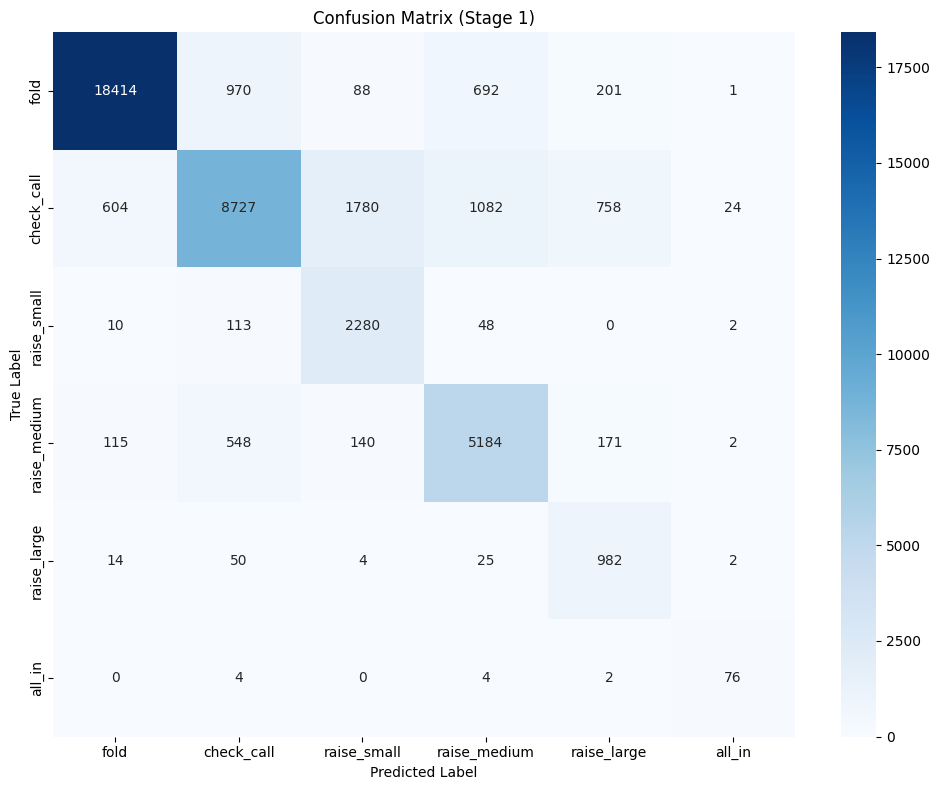

In [14]:
# Cell 14: Detailed Evaluation
model.eval()
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        probs = torch.softmax(outputs, dim=1)
        _, predicted = torch.max(outputs.data, 1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(y_batch.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

test_acc = 100 * np.mean(all_preds == all_labels)
print(f"Test Accuracy: {test_acc:.2f}%\n")

# Per-class metrics
print("Classification Report:")
print(classification_report(
    all_labels, 
    all_preds, 
    labels=list(range(N_ACTIONS)),
    target_names=ACTION_NAMES, 
    zero_division=0
))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=ACTION_NAMES, yticklabels=ACTION_NAMES)
plt.title('Confusion Matrix (Stage 1)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

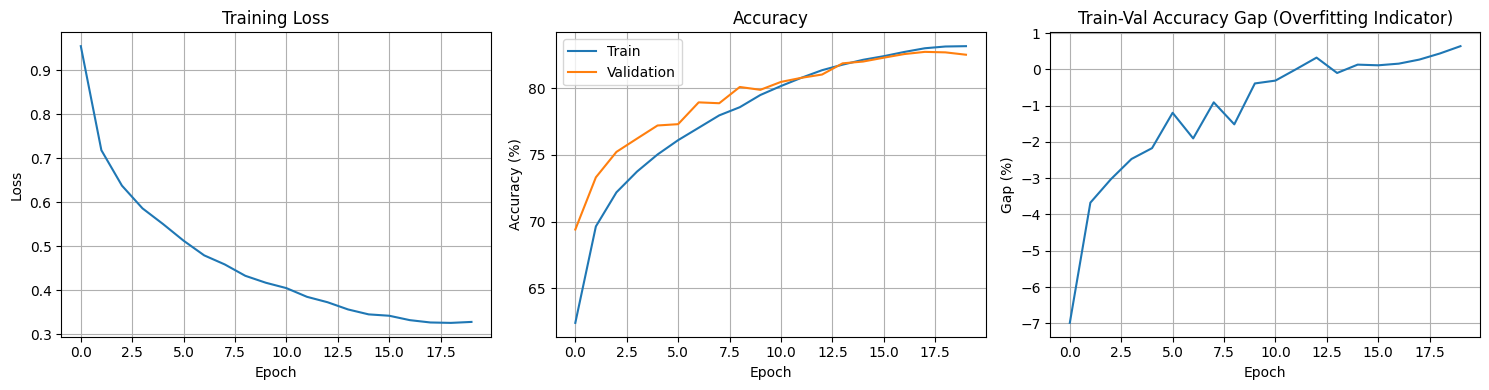

In [15]:
# Cell 15: Training Curves
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss
axes[0].plot(train_losses)
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True)

# Accuracy
axes[1].plot(train_accs, label='Train')
axes[1].plot(val_accs, label='Validation')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True)

# Train-Val Gap
gap = [t - v for t, v in zip(train_accs, val_accs)]
axes[2].plot(gap)
axes[2].set_title('Train-Val Accuracy Gap (Overfitting Indicator)')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Gap (%)')
axes[2].grid(True)

plt.tight_layout()
plt.show()

In [16]:
# Cell 16: Save Stage 1 Model
stage1_model_path = 'poker_stage1_model.pth'
torch.save({
    'model_state_dict': model.state_dict(),
    'config': CONFIG,
    'feature_dim': FEATURE_DIM,
    'n_actions': N_ACTIONS,
    'action_names': ACTION_NAMES,
    'best_val_acc': best_val_acc,
    'class_weights': class_weights,
}, stage1_model_path)
print(f"Stage 1 model saved to {stage1_model_path}")

Stage 1 model saved to poker_stage1_model.pth


In [17]:
# Cell 17: Poker Environment (for self-play and evaluation)
from treys import Card, Evaluator, Deck

class PokerGame:
    """6-player No-Limit Texas Hold'em Environment"""
    
    def __init__(self, n_players=6, starting_stack=10000, small_blind=50, big_blind=100):
        self.n_players = n_players
        self.starting_stack = starting_stack
        self.small_blind = small_blind
        self.big_blind = big_blind
        self.evaluator = Evaluator()
        self.reset()
    
    def reset(self):
        """Start a new hand"""
        self.deck = Deck()
        self.stacks = [self.starting_stack] * self.n_players
        self.pot = 0
        self.current_bets = [0] * self.n_players
        self.hole_cards = [[] for _ in range(self.n_players)]
        self.board_cards = []
        self.folded = [False] * self.n_players
        self.street = 'preflop'
        self.button = 0
        
        # Post blinds
        sb_pos = (self.button + 1) % self.n_players
        bb_pos = (self.button + 2) % self.n_players
        self.current_bets[sb_pos] = self.small_blind
        self.current_bets[bb_pos] = self.big_blind
        self.stacks[sb_pos] -= self.small_blind
        self.stacks[bb_pos] -= self.big_blind
        self.pot = self.small_blind + self.big_blind
        
        # Deal hole cards
        for i in range(self.n_players):
            self.hole_cards[i] = [self.deck.draw(1)[0], self.deck.draw(1)[0]]
        
        return self.get_state(0)
    
    def get_state(self, player_idx):
        """Get state from player's perspective (enhanced)"""
        n_active = sum(1 for i in range(self.n_players) if not self.folded[i])
        return {
            'street': self.street,
            'hole_cards': self.hole_cards[player_idx],
            'board_cards': self.board_cards.copy(),
            'pot': self.pot,
            'stack': self.stacks[player_idx],
            'starting_stack': self.starting_stack,
            'current_bet': self.current_bets[player_idx],
            'bet_to_call': max(self.current_bets) - self.current_bets[player_idx],
            'position': player_idx,
            'n_players': self.n_players,
            'n_active': n_active,
        }
    
    def step(self, player_idx, action_type, amount=0):
        """Execute an action"""
        if self.folded[player_idx]:
            return
        
        if action_type == 'fold':
            self.folded[player_idx] = True
        elif action_type == 'call':
            call_amount = max(self.current_bets) - self.current_bets[player_idx]
            call_amount = min(call_amount, self.stacks[player_idx])
            self.stacks[player_idx] -= call_amount
            self.current_bets[player_idx] += call_amount
            self.pot += call_amount
        elif action_type == 'raise':
            additional = amount - self.current_bets[player_idx]
            additional = min(additional, self.stacks[player_idx])
            self.stacks[player_idx] -= additional
            self.current_bets[player_idx] += additional
            self.pot += additional
    
    def advance_street(self):
        """Move to next betting round"""
        self.current_bets = [0] * self.n_players
        
        if self.street == 'preflop':
            self.board_cards = self.deck.draw(3)
            self.street = 'flop'
        elif self.street == 'flop':
            self.board_cards.extend(self.deck.draw(1))
            self.street = 'turn'
        elif self.street == 'turn':
            self.board_cards.extend(self.deck.draw(1))
            self.street = 'river'
        elif self.street == 'river':
            self.street = 'showdown'
    
    def is_betting_round_over(self):
        """Check if current betting round is complete"""
        active_players = [i for i in range(self.n_players) if not self.folded[i]]
        if len(active_players) <= 1:
            return True
        
        max_bet = max(self.current_bets)
        for i in active_players:
            if self.current_bets[i] < max_bet and self.stacks[i] > 0:
                return False
        return True
    
    def get_winners(self):
        """Determine winners and distribute pot"""
        active_players = [i for i in range(self.n_players) if not self.folded[i]]
        
        if len(active_players) == 1:
            return {active_players[0]: self.pot}
        
        # Showdown
        best_rank = float('inf')
        winners = []
        
        for player_idx in active_players:
            hand = self.hole_cards[player_idx]
            rank = self.evaluator.evaluate(self.board_cards, hand)
            
            if rank < best_rank:
                best_rank = rank
                winners = [player_idx]
            elif rank == best_rank:
                winners.append(player_idx)
        
        pot_per_winner = self.pot / len(winners)
        return {winner: pot_per_winner for winner in winners}

print("Poker environment ready")

Poker environment ready


In [18]:
# Cell 18: Bot Definitions

class BaseBot:
    """Base class for poker bots"""
    def __init__(self, name):
        self.name = name
    
    def get_action(self, state, game):
        raise NotImplementedError

class RandomBot(BaseBot):
    def get_action(self, state, game):
        actions = ['fold', 'call', 'raise']
        action = np.random.choice(actions)
        if action == 'raise':
            min_raise = max(game.current_bets) + game.big_blind
            max_raise = state['stack'] + state['current_bet']
            if min_raise >= max_raise:
                return ('call', 0)
            amount = np.random.randint(min_raise, max_raise + 1)
            return ('raise', amount)
        return (action, 0)

class TightPassiveBot(BaseBot):
    def get_action(self, state, game):
        hole_cards = state['hole_cards']
        rank1 = Card.get_rank_int(hole_cards[0])
        rank2 = Card.get_rank_int(hole_cards[1])
        is_pair = (rank1 == rank2)
        has_high_card = (rank1 >= 9 or rank2 >= 9)
        bet_to_call = state['bet_to_call']
        
        if not is_pair and not has_high_card and bet_to_call > 0:
            return ('fold', 0)
        if np.random.random() < 0.9:
            return ('call', 0)
        min_raise = max(game.current_bets) + game.big_blind
        amount = min(min_raise + state['pot'] // 2, state['stack'] + state['current_bet'])
        return ('raise', amount)

class LooseAggressiveBot(BaseBot):
    def get_action(self, state, game):
        bet_to_call = state['bet_to_call']
        if bet_to_call > state['stack'] * 0.5 and np.random.random() < 0.3:
            return ('fold', 0)
        if np.random.random() < 0.6:
            raise_size = np.random.uniform(0.5, 2.0) * state['pot']
            min_raise = max(game.current_bets) + game.big_blind
            amount = int(max(min_raise, raise_size))
            amount = min(amount, state['stack'] + state['current_bet'])
            return ('raise', amount)
        return ('call', 0)

class CallStationBot(BaseBot):
    def get_action(self, state, game):
        bet_to_call = state['bet_to_call']
        if bet_to_call >= state['stack'] * 0.8 and np.random.random() < 0.2:
            return ('fold', 0)
        if np.random.random() < 0.95:
            return ('call', 0)
        min_raise = max(game.current_bets) + game.big_blind
        amount = min(min_raise + state['pot'] // 3, state['stack'] + state['current_bet'])
        return ('raise', amount)

print("Rule-based bots ready")

Rule-based bots ready


In [19]:
# Cell 19: Enhanced Model Player with proper card conversion

class ModelPlayer(BaseBot):
    """Wrapper for trained MLP model with enhanced features"""
    def __init__(self, model, name="ModelPlayer", temperature=1.0, device='cpu'):
        super().__init__(name)
        self.model = model
        self.model.eval()
        self.temperature = temperature  # For action sampling (1.0 = argmax)
        self.device = device
    
    def treys_card_to_string(self, card):
        """Convert treys card integer to string format like 'Ah'"""
        rank_int = Card.get_rank_int(card)
        suit_int = Card.get_suit_int(card)
        
        rank_chars = '23456789TJQKA'
        suit_map = {1: 's', 2: 'h', 4: 'd', 8: 'c'}
        
        rank_char = rank_chars[rank_int]
        suit_char = suit_map.get(suit_int, 'c')
        
        return rank_char + suit_char
    
    def state_to_features(self, state):
        """Convert game state to feature vector"""
        # Convert treys cards to string format
        hole_cards_str = [self.treys_card_to_string(c) for c in state['hole_cards']]
        board_cards_str = [self.treys_card_to_string(c) for c in state['board_cards']]
        
        # Create state dict with string cards
        state_for_features = {
            'street': state['street'],
            'hole_cards': hole_cards_str,
            'board_cards': board_cards_str,
            'pot': state['pot'],
            'stack': state['stack'],
            'starting_stack': state.get('starting_stack', 10000),
            'current_bet': state.get('current_bet', 0),
            'bet_to_call': state['bet_to_call'],
            'position': state['position'],
            'n_players': state['n_players'],
            'n_active': state.get('n_active', state['n_players']),
        }
        
        return state_to_features_enhanced(state_for_features)
    
    def get_action(self, state, game):
        """Get action from model prediction"""
        features = self.state_to_features(state)
        features_tensor = torch.FloatTensor(features).unsqueeze(0).to(self.device)
        
        with torch.no_grad():
            outputs = self.model(features_tensor)
            
            if self.temperature <= 0.01:  # Essentially argmax
                action_idx = torch.argmax(outputs, dim=1).item()
            else:
                # Sample from softmax with temperature
                probs = torch.softmax(outputs / self.temperature, dim=1)
                action_idx = torch.multinomial(probs, 1).item()
        
        # Convert action index to actual action
        if action_idx == 0:  # fold
            return ('fold', 0)
        elif action_idx == 1:  # check_call
            return ('call', 0)
        else:
            # Raise actions
            pot = state['pot']
            stack = state['stack']
            current_bet = state.get('current_bet', 0)
            min_raise = max(game.current_bets) + game.big_blind
            
            if action_idx == 2:  # raise_small
                raise_size = pot * 0.5
            elif action_idx == 3:  # raise_medium
                raise_size = pot * 1.0
            elif action_idx == 4:  # raise_large
                raise_size = pot * 2.0
            else:  # all_in
                raise_size = stack
            
            amount = int(max(min_raise, current_bet + raise_size))
            amount = min(amount, stack + current_bet)
            
            return ('raise', amount)

print("Model player ready")

Model player ready


In [20]:
# Cell 20: Simulation with Rotation

def simulate_hand_with_fixed_deck(game, players, deck_cards):
    """Simulate one hand with a fixed deck"""
    game.deck = Deck()
    game.deck.cards = deck_cards.copy()
    
    game.stacks = [game.starting_stack] * game.n_players
    game.pot = 0
    game.current_bets = [0] * game.n_players
    game.hole_cards = [[] for _ in range(game.n_players)]
    game.board_cards = []
    game.folded = [False] * game.n_players
    game.street = 'preflop'
    game.button = 0
    
    # Post blinds
    sb_pos = (game.button + 1) % game.n_players
    bb_pos = (game.button + 2) % game.n_players
    game.current_bets[sb_pos] = game.small_blind
    game.current_bets[bb_pos] = game.big_blind
    game.stacks[sb_pos] -= game.small_blind
    game.stacks[bb_pos] -= game.big_blind
    game.pot = game.small_blind + game.big_blind
    
    # Deal hole cards
    for i in range(game.n_players):
        game.hole_cards[i] = [game.deck.draw(1)[0], game.deck.draw(1)[0]]
    
    # Betting rounds
    for street_num in range(4):
        acting_player = (game.button + 3) % game.n_players
        players_acted = [False] * game.n_players
        
        for _ in range(20):  # Max iterations per street
            if game.is_betting_round_over():
                break
            
            if not game.folded[acting_player] and not players_acted[acting_player]:
                state = game.get_state(acting_player)
                action_type, amount = players[acting_player].get_action(state, game)
                game.step(acting_player, action_type, amount)
                players_acted[acting_player] = True
            
            acting_player = (acting_player + 1) % game.n_players
        
        active_players = [i for i in range(game.n_players) if not game.folded[i]]
        if len(active_players) <= 1:
            break
        
        if street_num < 3:
            game.advance_street()
    
    return game.get_winners()

def simulate_games_with_rotation(players, n_hands=1000, starting_stack=10000, verbose=True):
    """Simulate games with position rotation for fair evaluation"""
    game = PokerGame(n_players=len(players), starting_stack=starting_stack)
    n_players = len(players)
    total_profits = [0.0] * n_players
    
    for hand_num in range(n_hands):
        deck = Deck()
        original_deck = deck.cards.copy()
        
        for rotation in range(n_players):
            rotated_players = players[rotation:] + players[:rotation]
            winners = simulate_hand_with_fixed_deck(game, rotated_players, original_deck)
            
            for i in range(n_players):
                original_idx = (i - rotation) % n_players
                profit = (game.stacks[i] + winners.get(i, 0)) - starting_stack
                total_profits[original_idx] += profit
        
        if verbose and (hand_num + 1) % 200 == 0:
            print(f"  Completed {hand_num + 1}/{n_hands} hands")
    
    return total_profits

print("Simulation functions ready")

Simulation functions ready


In [21]:
# Cell 21: Comprehensive Evaluation Against Multiple Bot Types
print("=" * 60)
print("COMPREHENSIVE EVALUATION - Stage 1 Model vs Various Opponents")
print("=" * 60)

model_player = ModelPlayer(model, "Stage1_Model", temperature=0.0, device=device)

opponents = [
    ("TightPassive", TightPassiveBot("TightPassive")),
    ("LooseAggressive", LooseAggressiveBot("LooseAggressive")),
    ("CallStation", CallStationBot("CallStation")),
    ("Random", RandomBot("Random")),
]

results = {}
n_hands = 500  # Per opponent

for opp_name, opp_bot in opponents:
    print(f"\n--- vs {opp_name} ---")
    players = [model_player, opp_bot]
    profits = simulate_games_with_rotation(players, n_hands=n_hands, verbose=False)
    
    actual_hands = n_hands * len(players)
    bb_per_100 = [(p / actual_hands) * 100 / 100 for p in profits]  # bb=100
    
    results[opp_name] = bb_per_100[0]
    print(f"  Model: {bb_per_100[0]:+.2f} bb/100")
    print(f"  {opp_name}: {bb_per_100[1]:+.2f} bb/100")

# Summary
print("\n" + "=" * 60)
print("SUMMARY")
print("=" * 60)
for opp, bb in results.items():
    status = "WIN" if bb > 0 else "LOSE"
    print(f"  vs {opp:20s}: {bb:+8.2f} bb/100 [{status}]")

avg_bb = np.mean(list(results.values()))
print(f"\n  Average: {avg_bb:+.2f} bb/100")

COMPREHENSIVE EVALUATION - Stage 1 Model vs Various Opponents

--- vs TightPassive ---
  Model: +17.77 bb/100
  TightPassive: -17.77 bb/100

--- vs LooseAggressive ---
  Model: +10.57 bb/100
  LooseAggressive: -10.57 bb/100

--- vs CallStation ---
  Model: +0.60 bb/100
  CallStation: -0.60 bb/100

--- vs Random ---
  Model: +274.60 bb/100
  Random: -274.60 bb/100

SUMMARY
  vs TightPassive        :   +17.77 bb/100 [WIN]
  vs LooseAggressive     :   +10.57 bb/100 [WIN]
  vs CallStation         :    +0.60 bb/100 [WIN]
  vs Random              :  +274.60 bb/100 [WIN]

  Average: +75.89 bb/100


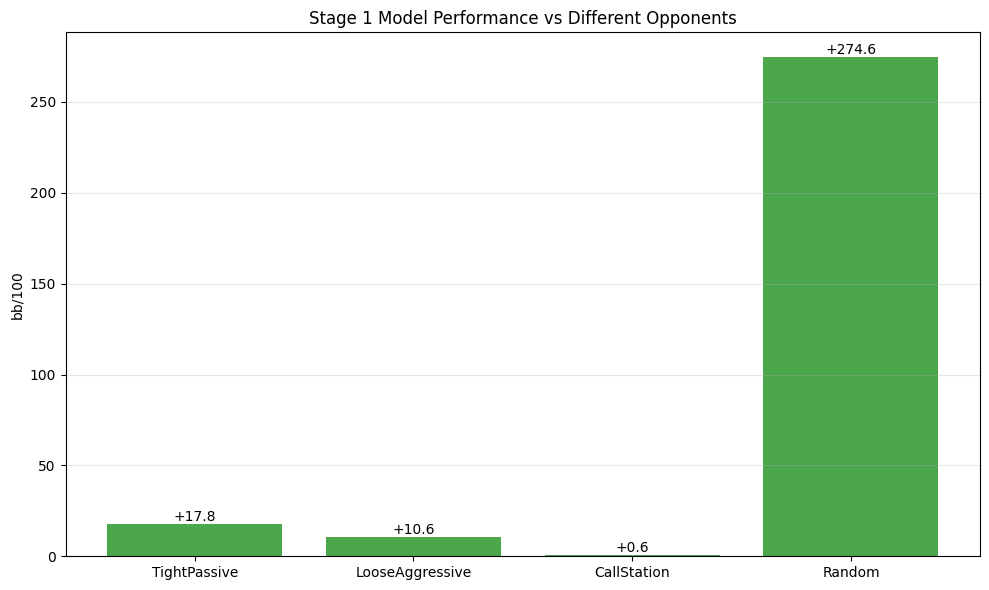

In [22]:
# Cell 22: Results Visualization
fig, ax = plt.subplots(figsize=(10, 6))

opponents_list = list(results.keys())
bb_values = list(results.values())
colors = ['green' if bb > 0 else 'red' for bb in bb_values]

bars = ax.bar(opponents_list, bb_values, color=colors, alpha=0.7)
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.set_ylabel('bb/100')
ax.set_title('Stage 1 Model Performance vs Different Opponents')
ax.grid(axis='y', alpha=0.3)

for bar, value in zip(bars, bb_values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{value:+.1f}',
            ha='center', va='bottom' if height > 0 else 'top')

plt.tight_layout()
plt.show()

---
# Stage 1.5: Self-Play Fine-Tuning (OPTIONAL - SKIP FOR NOW)

**Note**: This section is optional and currently disabled. The Stage 1 model already performs well.
Self-play with vanilla policy gradient tends to degrade performance. 
Proper reinforcement learning (PPO, A2C) will be implemented in Stage 2.

If you want to experiment, uncomment and run the cells below.
---

In [23]:
# Cell 23: Self-Play Training Setup (FIXED - BatchNorm compatible)

class SelfPlayTrainer:
    """
    Self-play fine-tuning for poker model.
    Uses simple policy gradient with reward shaping.
    FIXED: Properly handles BatchNorm by using eval() during inference
    and batching samples before training update.
    """
    def __init__(self, model, device='cpu', lr=0.0001, entropy_coef=0.01):
        self.model = model
        self.device = device
        self.optimizer = optim.Adam(model.parameters(), lr=lr)
        self.entropy_coef = entropy_coef

        # Opponent pool (copies of model at different stages)
        self.opponent_pool = []
        self.add_to_opponent_pool()

    def add_to_opponent_pool(self):
        """Add current model to opponent pool"""
        model_copy = PokerMLP(
            input_dim=FEATURE_DIM,
            hidden_dims=CONFIG['hidden_dims'],
            output_dim=N_ACTIONS
        ).to(self.device)
        model_copy.load_state_dict(self.model.state_dict())
        model_copy.eval()
        self.opponent_pool.append(model_copy)
        if len(self.opponent_pool) > 5:
            self.opponent_pool.pop(0)

    def get_opponent(self):
        """Sample opponent from pool"""
        idx = np.random.randint(len(self.opponent_pool))
        return ModelPlayer(self.opponent_pool[idx], "Opponent", temperature=0.5, device=self.device)

    def collect_episode(self, game, players):
        """
        Play one hand and collect (state, action, reward) tuples for the learning player.
        FIXED: Use eval() mode for inference, store features for later batched gradient computation.
        """
        game.reset()

        # Store features and actions (compute log_probs later in batch)
        episode_data = []  # (features, action_idx)

        for street_num in range(4):
            acting_player = (game.button + 3) % game.n_players
            players_acted = [False] * game.n_players

            for _ in range(20):
                if game.is_betting_round_over():
                    break

                if not game.folded[acting_player] and not players_acted[acting_player]:
                    state = game.get_state(acting_player)

                    if acting_player == 0:  # Learning agent
                        features = players[0].state_to_features(state)
                        features_tensor = torch.FloatTensor(features).unsqueeze(0).to(self.device)

                        # FIXED: Use eval() mode for inference (avoids BatchNorm error with batch_size=1)
                        self.model.eval()
                        with torch.no_grad():
                            logits = self.model(features_tensor)
                            probs = torch.softmax(logits, dim=1)
                            action_idx = torch.multinomial(probs, 1).item()

                        # Store features and action for later batched gradient computation
                        episode_data.append((features.copy(), action_idx))

                        # Execute action
                        action_type, amount = self._idx_to_action(action_idx, state, game)
                        game.step(acting_player, action_type, amount)
                    else:
                        # Opponent action (always in eval mode via ModelPlayer)
                        action_type, amount = players[acting_player].get_action(state, game)
                        game.step(acting_player, action_type, amount)

                    players_acted[acting_player] = True

                acting_player = (acting_player + 1) % game.n_players

            active_players = [i for i in range(game.n_players) if not game.folded[i]]
            if len(active_players) <= 1:
                break

            if street_num < 3:
                game.advance_street()

        winners = game.get_winners()
        reward = (game.stacks[0] + winners.get(0, 0)) - game.starting_stack
        reward = reward / game.starting_stack  # Normalize

        return episode_data, reward

    def _idx_to_action(self, action_idx, state, game):
        """Convert action index to action tuple"""
        if action_idx == 0:
            return ('fold', 0)
        elif action_idx == 1:
            return ('call', 0)
        else:
            pot = state['pot']
            stack = state['stack']
            current_bet = state.get('current_bet', 0)
            min_raise = max(game.current_bets) + game.big_blind

            if action_idx == 2:
                raise_size = pot * 0.5
            elif action_idx == 3:
                raise_size = pot * 1.0
            elif action_idx == 4:
                raise_size = pot * 2.0
            else:
                raise_size = stack

            amount = int(max(min_raise, current_bet + raise_size))
            amount = min(amount, stack + current_bet)
            return ('raise', amount)

    def train_epoch(self, n_games=1000):
        """Train for one epoch of self-play games"""
        game = PokerGame(n_players=2, starting_stack=10000)

        total_loss = 0
        total_reward = 0
        n_updates = 0

        # FIXED: Collect features/actions first, then do batched update
        batch_features = []
        batch_actions = []
        batch_rewards = []
        batch_size = 64  # Ensure batch_size > 1 for BatchNorm

        for game_num in range(n_games):
            # Get opponent
            if np.random.random() < 0.5 and len(self.opponent_pool) > 0:
                opponent = self.get_opponent()
            else:
                opponent = ModelPlayer(self.model, "Self", temperature=0.5, device=self.device)

            learning_player = ModelPlayer(self.model, "Learner", temperature=0.5, device=self.device)
            players = [learning_player, opponent]

            episode_data, reward = self.collect_episode(game, players)

            # Add episode data to batch
            if episode_data:
                for features, action_idx in episode_data:
                    batch_features.append(features)
                    batch_actions.append(action_idx)
                    batch_rewards.append(reward)

            total_reward += reward

            # FIXED: Update with proper batch size for BatchNorm
            if len(batch_features) >= batch_size:
                self.optimizer.zero_grad()

                # Create batch tensors
                features_tensor = torch.FloatTensor(np.array(batch_features)).to(self.device)
                actions_tensor = torch.LongTensor(batch_actions).to(self.device)
                rewards_tensor = torch.FloatTensor(batch_rewards).to(self.device)

                # Normalize rewards
                rewards_tensor = (rewards_tensor - rewards_tensor.mean()) / (rewards_tensor.std() + 1e-8)

                # Forward pass in training mode (batch_size > 1, so BatchNorm works)
                self.model.train()
                logits = self.model(features_tensor)

                # Compute log probabilities for selected actions
                log_probs = torch.log_softmax(logits, dim=1)
                selected_log_probs = log_probs.gather(1, actions_tensor.unsqueeze(1)).squeeze(1)

                # Policy gradient loss: maximize reward
                loss = -(selected_log_probs * rewards_tensor).mean()

                # Add entropy bonus for exploration
                probs = torch.softmax(logits, dim=1)
                entropy = -(probs * log_probs).sum(dim=1).mean()
                loss = loss - self.entropy_coef * entropy

                loss.backward()
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
                self.optimizer.step()

                total_loss += loss.item()
                n_updates += 1

                # Clear batch
                batch_features = []
                batch_actions = []
                batch_rewards = []

        avg_loss = total_loss / max(n_updates, 1)
        avg_reward = total_reward / n_games

        return avg_loss, avg_reward

print("Self-play trainer ready (FIXED)")

Self-play trainer ready (FIXED)


In [24]:
# STAGE 1.5 DISABLED - Skip to Cell 27 to save Stage 1 model
# Uncomment below to run self-play (not recommended - use Stage 2 RL instead)

"""
print("=" * 60)
print("STAGE 1.5: SELF-PLAY FINE-TUNING")
print("=" * 60)

trainer = SelfPlayTrainer(
    model, 
    device=device, 
    lr=CONFIG['selfplay_lr'],
    entropy_coef=0.01
)

selfplay_losses = []
selfplay_rewards = []

for epoch in range(CONFIG['selfplay_epochs']):
    loss, reward = trainer.train_epoch(n_games=CONFIG['selfplay_games_per_epoch'])
    selfplay_losses.append(loss)
    selfplay_rewards.append(reward)
    
    print(f"Epoch {epoch+1}/{CONFIG['selfplay_epochs']}: Loss={loss:.4f}, Avg Reward={reward:.4f}")
    
    if (epoch + 1) % 2 == 0:
        trainer.add_to_opponent_pool()
        print(f"  Added model to opponent pool (size: {len(trainer.opponent_pool)})")

print("
Self-play fine-tuning complete!")
"""

print("Stage 1.5 skipped - proceeding to save Stage 1 model")

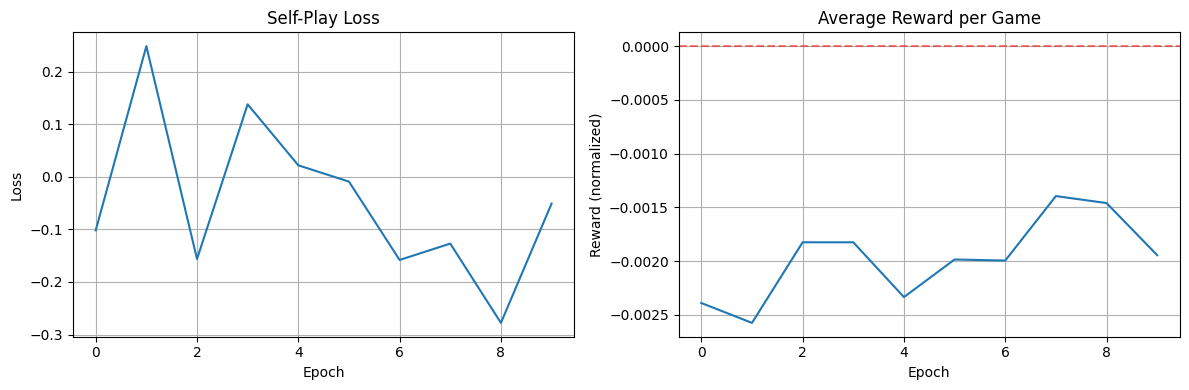

In [25]:
# Cell 25: Self-Play Training Curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(selfplay_losses)
ax1.set_title('Self-Play Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.grid(True)

ax2.plot(selfplay_rewards)
ax2.set_title('Average Reward per Game')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Reward (normalized)')
ax2.axhline(y=0, color='r', linestyle='--', alpha=0.5)
ax2.grid(True)

plt.tight_layout()
plt.show()

In [26]:
# Cell 26: Post Self-Play Evaluation
print("=" * 60)
print("POST SELF-PLAY EVALUATION")
print("=" * 60)

model_player_sp = ModelPlayer(model, "Stage1.5_Model", temperature=0.0, device=device)

results_post = {}

for opp_name, opp_bot in opponents:
    print(f"\n--- vs {opp_name} ---")
    players = [model_player_sp, opp_bot]
    profits = simulate_games_with_rotation(players, n_hands=500, verbose=False)
    
    actual_hands = 500 * len(players)
    bb_per_100 = [(p / actual_hands) * 100 / 100 for p in profits]
    
    results_post[opp_name] = bb_per_100[0]
    print(f"  Model: {bb_per_100[0]:+.2f} bb/100")

# Comparison
print("\n" + "=" * 60)
print("COMPARISON: Before vs After Self-Play")
print("=" * 60)
print(f"{'Opponent':<20} {'Before':>12} {'After':>12} {'Change':>12}")
print("-" * 56)
for opp in results.keys():
    before = results[opp]
    after = results_post[opp]
    change = after - before
    print(f"{opp:<20} {before:>+12.2f} {after:>+12.2f} {change:>+12.2f}")

avg_before = np.mean(list(results.values()))
avg_after = np.mean(list(results_post.values()))
print("-" * 56)
print(f"{'Average':<20} {avg_before:>+12.2f} {avg_after:>+12.2f} {avg_after-avg_before:>+12.2f}")

POST SELF-PLAY EVALUATION

--- vs TightPassive ---
  Model: +7.60 bb/100

--- vs LooseAggressive ---
  Model: -7.37 bb/100

--- vs CallStation ---
  Model: -2.90 bb/100

--- vs Random ---
  Model: +195.72 bb/100

COMPARISON: Before vs After Self-Play
Opponent                   Before        After       Change
--------------------------------------------------------
TightPassive               +17.77        +7.60       -10.17
LooseAggressive            +10.57        -7.37       -17.94
CallStation                 +0.60        -2.90        -3.50
Random                    +274.60      +195.72       -78.88
--------------------------------------------------------
Average                    +75.89       +48.26       -27.62


In [27]:
# Cell 27: Save Final Model (Stage 1)
final_model_path = 'poker_stage1_final.pth'
torch.save({
    'model_state_dict': model.state_dict(),
    'config': CONFIG,
    'feature_dim': FEATURE_DIM,
    'n_actions': N_ACTIONS,
    'action_names': ACTION_NAMES,
    'stage1_val_acc': best_val_acc,
    'evaluation_results': results,
}, final_model_path)
print(f"Stage 1 model saved to {final_model_path}")

print("
" + "=" * 60)
print("STAGE 1 COMPLETE")
print("=" * 60)
print(f"
Best Validation Accuracy: {best_val_acc:.2f}%")
print(f"Average bb/100 vs opponents: {np.mean(list(results.values())):+.2f}")
print("
Next steps for Stage 2 (Reinforcement Learning):")
print("1. Implement PPO or A2C algorithm")
print("2. Add value network for advantage estimation")
print("3. Train against diverse opponents or self-play")
print("4. Consider CFR integration for GTO play")